# 📊 Repaso: Módulo de Inferencia Estadística (preguntas de alternativas)

Este notebook contiene **25 preguntas de opción múltiple** organizadas por tema. Todas se resuelven usando un **dataset simulado** (un DataFrame de `pandas`) que representa a los empleados de una empresa ficticia, "Datalytics S.A.".

## Temas cubiertos
1. Probabilidad clásica
2. Tabla de doble entrada
3. Árbol de probabilidades (unión, intersección, probabilidad condicional)
4. Distribución normal
5. Intervalos de confianza para la media
6. Pruebas de hipótesis para la media
7. p-valor
8. Tipos de muestreo (aleatorio simple, estratificado, por conglomerados)

## Cómo usar este notebook
- Cada pregunta tiene un enunciado con **4 alternativas (a, b, c, d)**.
- Justo debajo, hay una celda de código con el **desarrollo en Python** (los cálculos necesarios) ya lista para ejecutar — pero **no indica cuál alternativa es la correcta**. Ejecutá la celda, mirá el resultado numérico y elegí vos la alternativa que corresponde.
- Al final del notebook está la sección **✅ Clave de respuestas**, con solo la letra correcta de cada pregunta, para que te autocorrijas.

---


## 🔧 Preparación del entorno

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
np.random.seed(42)  # semilla para reproducibilidad


## 🗂️ Generación del dataset simulado

Simulamos una base de datos con **500 empleados** de la empresa "Datalytics S.A.", con las siguientes columnas:

| Columna | Descripción |
|---|---|
| `id_empleado` | Identificador único |
| `departamento` | Ventas, Marketing, IT, RRHH u Operaciones |
| `genero` | Femenino o Masculino |
| `region` | Norte, Centro o Sur (sucursal donde trabaja) |
| `edad` | Edad del empleado (años) |
| `antiguedad_anios` | Años de antigüedad en la empresa |
| `salario_mensual` | Salario mensual (en miles de pesos), distribuido de forma aproximadamente normal |
| `horas_capacitacion` | Horas de capacitación recibidas en el último año |
| `satisfaccion` | Nivel de satisfacción laboral: Baja, Media o Alta |
| `turno` | Mañana o Tarde |

Este dataset se reutiliza en **todas** las preguntas del notebook.

In [ ]:
n = 500

departamentos = np.random.choice(
    ['Ventas', 'Marketing', 'IT', 'RRHH', 'Operaciones'],
    size=n,
    p=[0.30, 0.15, 0.25, 0.10, 0.20]
)

genero = np.random.choice(
    ['Femenino', 'Masculino'],
    size=n,
    p=[0.48, 0.52]
)

region = np.random.choice(
    ['Norte', 'Centro', 'Sur'],
    size=n,
    p=[0.25, 0.50, 0.25]
)

edad = np.random.randint(22, 60, size=n)

antiguedad_anios = np.round(
    np.random.exponential(scale=4, size=n) + 0.2,
    1
)
antiguedad_anios = np.clip(
    antiguedad_anios, 0.2, 30
)

# Salario con distribución aproximadamente normal (en miles de pesos)
salario_mensual = np.round(
    np.random.normal(loc=1200, scale=180, size=n),
    0
)
salario_mensual = np.clip(
    salario_mensual, 500, None
)

horas_capacitacion = np.round(
    np.random.normal(loc=20, scale=8, size=n),
    0
)
horas_capacitacion = np.clip(
    horas_capacitacion, 0, None
)

satisfaccion = np.random.choice(
    ['Baja', 'Media', 'Alta'],
    size=n,
    p=[0.20, 0.45, 0.35]
)

turno = np.random.choice(
    ['Mañana', 'Tarde'],
    size=n,
    p=[0.6, 0.4]
)

df = pd.DataFrame({
    'id_empleado': np.arange(1, n + 1),
    'departamento': departamentos,
    'genero': genero,
    'region': region,
    'edad': edad,
    'antiguedad_anios': antiguedad_anios,
    'salario_mensual': salario_mensual,
    'horas_capacitacion': horas_capacitacion,
    'satisfaccion': satisfaccion,
    'turno': turno
})

df.head()


,id_empleado,departamento,genero,region,edad,antiguedad_anios,salario_mensual,horas_capacitacion,satisfaccion,turno
0,1,Marketing,Masculino,Norte,23,7.5,1044.0,20.0,Media,Mañana
1,2,Operaciones,Masculino,Centro,27,7.4,1238.0,23.0,Media,Tarde
2,3,RRHH,Femenino,Sur,49,0.2,1219.0,23.0,Alta,Tarde
3,4,IT,Masculino,Centro,50,5.7,1415.0,10.0,Alta,Mañana
4,5,Ventas,Masculino,Sur,47,5.9,1249.0,21.0,Alta,Mañana


In [ ]:
df.shape

(500, 10)

---
## 1️⃣ Probabilidad clásica

Recordá la **regla de Laplace**:

$$P(A) = \frac{\text{casos favorables}}{\text{casos posibles}}$$

### ❓ Pregunta 1
Si elegimos un empleado al azar del dataset, ¿cuál es la probabilidad de que trabaje en el departamento de **IT**?

- **a)** 0.246
- **b)** 0.138
- **c)** 0.212
- **d)** 0.308


In [ ]:
# Tabla de frecuencias de la variable departamento
tabla_departamento = df["departamento"].value_counts().sort_index()
print(tabla_departamento)




departamento
IT             123
Marketing       69
Operaciones    106
RRHH            48
Ventas         154
Name: count, dtype: int64


In [ ]:
123/500

0.246

### ❓ Pregunta 2
¿Cuál es la probabilidad de que un empleado elegido al azar tenga **más de 45 años**?

- **a)** 0.358
- **b)** 0.500
- **c)** 0.246
- **d)** 0.642


In [ ]:
# Tabla de frecuencias agrupada para la edad
bins = [20, 30, 40, 45, 50, 60]
labels = ["21-30", "31-40", "41-45", "46-50", "51-59"]

tabla_edad = pd.cut(
    df["edad"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
).value_counts().sort_index()

print(tabla_edad)


edad
21-30    119
31-40    125
41-45     77
46-50     61
51-59    118
Name: count, dtype: int64


In [ ]:
(61+118)/500


0.358

---
## 2️⃣ Tabla de doble entrada (tabla de contingencia)

Una tabla de doble entrada cruza dos variables categóricas y nos permite calcular probabilidades conjuntas, marginales y condicionales.

### ❓ Pregunta 3
Construyendo la tabla de contingencia entre `departamento` y `genero`, ¿cuántos empleados son de género **Femenino** y trabajan en **Ventas**?

- **a)** 69
- **b)** 85
- **c)** 154
- **d)** 59


In [ ]:
tabla_depto_genero = pd.crosstab(df['departamento'], df['genero'])
print(tabla_depto_genero)


genero        Femenino  Masculino
departamento                     
IT                  59         64
Marketing           30         39
Operaciones         54         52
RRHH                25         23
Ventas              85         69


### ❓ Pregunta 4
A partir de la tabla anterior, ¿cuál es la probabilidad de que un empleado elegido al azar sea del género **Femenino** *y* trabaje en **Ventas**?

- **a)** 0.308
- **b)** 0.552
- **c)** 0.138
- **d)** 0.170


In [ ]:
85/500

0.17

In [ ]:
# Tabla de doble entrada: departamento × género
tabla_depto_genero = pd.crosstab(
    df["departamento"],
    df["genero"],
    margins=True
)

print(tabla_depto_genero)




genero        Femenino  Masculino  All
departamento                          
IT                  59         64  123
Marketing           30         39   69
Operaciones         54         52  106
RRHH                25         23   48
Ventas              85         69  154
All                253        247  500


### ❓ Pregunta 5
Usando la tabla de doble entrada entre `region` y `satisfaccion`, ¿cuál es la probabilidad de que un empleado tenga satisfacción **Alta**, dado que trabaja en la región **Sur**?

- **a)** 0.230
- **b)** 0.336
- **c)** 0.248
- **d)** 0.416


In [ ]:
# Tabla de doble entrada: región × satisfacción
tabla_region_satisf = pd.crosstab(
    df["region"],
    df["satisfaccion"],
    margins=True
)

print(tabla_region_satisf)




satisfaccion  Alta  Baja  Media  All
region                              
Centro          80    45    108  233
Norte           42    31     57  130
Sur             46    34     57  137
All            168   110    222  500


In [ ]:
46/137

0.3357664233576642

In [ ]:
# P(A/B)=P(A inter B)/P(B)

---
## 3️⃣ Árbol de probabilidades

Un árbol de probabilidades es útil para representar experimentos en **etapas sucesivas** y calcular probabilidades condicionales y conjuntas paso a paso. Vamos a construir un árbol para el experimento: *"elegir un empleado al azar y observar su `turno` (Mañana/Tarde) y luego su `satisfaccion` (Baja/Media/Alta)"*.

### ❓ Pregunta 6
En el primer nivel del árbol (el `turno`), ¿cuál es la probabilidad de la rama **Tarde**?

- **a)** 0.500
- **b)** 0.622
- **c)** 0.378
- **d)** 0.302


In [ ]:
p_turno = df['turno'].value_counts(normalize=True)
print("Probabilidades de turno:")
print(p_turno, "\n")

p_satisf_dado_turno = pd.crosstab(df['turno'], df['satisfaccion'], normalize='index')
print("P(satisfaccion | turno):")
print(p_satisf_dado_turno)


Probabilidades de turno:
turno
Mañana    0.622
Tarde     0.378
Name: proportion, dtype: float64 

P(satisfaccion | turno):
satisfaccion      Alta      Baja     Media
turno                                     
Mañana        0.302251  0.231511  0.466238
Tarde         0.391534  0.201058  0.407407


### ❓ Pregunta 7
Siguiendo la rama del árbol turno=Mañana y luego satisfacción=Alta, ¿cuál es la probabilidad conjunta $P(\text{Mañana} \cap \text{Alta})$?

- **a)** 0.188
- **b)** 0.466
- **c)** 0.622
- **d)** 0.302


In [ ]:
# Tabla de doble entrada: turno × satisfacción
tabla_turno_satisf = pd.crosstab(
    df["turno"],
    df["satisfaccion"],
    margins=True
)

print(tabla_turno_satisf)



satisfaccion  Alta  Baja  Media  All
turno                               
Mañana          94    72    145  311
Tarde           74    38     77  189
All            168   110    222  500


In [ ]:
# P(A/M)

94/311

0.3022508038585209

In [ ]:
#P(A Y M)

0.622*0.302

0.18784399999999998

---
## 4️⃣ Unión e intersección de eventos

En esta sección **no calcularemos directamente las probabilidades mediante código**.
El código solo construirá una **tabla de doble entrada con frecuencias y totales marginales**.

Sean los eventos:
- **A** = "el empleado trabaja en Marketing"
- **B** = "el empleado tiene satisfacción Alta"

Recuerda:

$$P(A \cap B) = \frac{n(A \cap B)}{n(\Omega)}$$

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

El objetivo es que identifiques las frecuencias necesarias en la tabla y realices el cálculo.


### ❓ Pregunta 8
¿Cuál es el valor de $P(A \cap B)$ (intersección)?

- **a)** 0.182
- **b)** 0.044
- **c)** 0.336
- **d)** 0.138


In [ ]:
# Tabla de doble entrada: departamento × satisfacción
tabla_depto_satisf = pd.crosstab(
    df["departamento"],
    df["satisfaccion"],
    margins=True
)

print(tabla_depto_satisf)



satisfaccion  Alta  Baja  Media  All
departamento                        
IT              45    32     46  123
Marketing       22    13     34   69
Operaciones     30    23     53  106
RRHH            19     6     23   48
Ventas          52    36     66  154
All            168   110    222  500


In [ ]:
22/500

0.044

### ❓ Pregunta 9
¿Cuál es el valor de $P(A \cup B)$?

- **a)** 0.336
- **b)** 0.474
- **c)** 0.430
- **d)** 0.044


In [ ]:
# Tabla de doble entrada con totales marginales
tabla_depto_satisf_union = pd.crosstab(
    df["departamento"],
    df["satisfaccion"],
    margins=True
)

print(tabla_depto_satisf_union)




satisfaccion  Alta  Baja  Media  All
departamento                        
IT              45    32     46  123
Marketing       22    13     34   69
Operaciones     30    23     53  106
RRHH            19     6     23   48
Ventas          52    36     66  154
All            168   110    222  500


In [ ]:
69/500+168/500-22/500

0.43000000000000005

---
## 5️⃣ Probabilidad condicional

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

### ❓ Pregunta 10
¿Cuál es la probabilidad de que un empleado tenga **antigüedad mayor a 5 años**, dado que trabaja en **Operaciones**?

- **a)** 0.076
- **b)** 0.358
- **c)** 0.500
- **d)** 0.642


In [ ]:
operaciones = df[df['departamento'] == 'Operaciones']
p_antig_mayor5_dado_operaciones = (operaciones['antiguedad_anios'] > 5).mean()
print(f"P(antiguedad > 5 | Operaciones) = {p_antig_mayor5_dado_operaciones:.4f}")


P(antiguedad > 5 | Operaciones) = 0.3585


### ❓ Pregunta 11
¿Cuál es la probabilidad de que un empleado sea del género **Masculino**, dado que su satisfacción es **Baja**?

- **a)** 0.455
- **b)** 0.100
- **c)** 0.250
- **d)** 0.545


In [ ]:
baja_satisf = df[df['satisfaccion'] == 'Baja']
p_masculino_dado_baja = (baja_satisf['genero'] == 'Masculino').mean()
print(f"P(Masculino | Satisfaccion Baja) = {p_masculino_dado_baja:.4f}")


P(Masculino | Satisfaccion Baja) = 0.4545


### ❓ Pregunta 12
Comparando $P(\text{RRHH})$ con $P(\text{RRHH} \mid \text{Alta})$, ¿qué se puede concluir sobre los eventos "trabajar en RRHH" y "tener satisfacción Alta"?

- **a)** Son aproximadamente independientes, porque P(RRHH) ≈ P(RRHH | Alta)
- **b)** No son independientes, porque P(RRHH) es mucho mayor que P(RRHH | Alta)
- **c)** No son independientes, porque P(RRHH | Alta) = 0
- **d)** No se puede determinar la independencia con estos datos


In [ ]:
p_rrhh = (df['departamento'] == 'RRHH').mean()

alta_satisf = df[df['satisfaccion'] == 'Alta']
p_rrhh_dado_alta = (alta_satisf['departamento'] == 'RRHH').mean()

print(f"P(RRHH) = {p_rrhh:.4f}")
print(f"P(RRHH | Alta) = {p_rrhh_dado_alta:.4f}")


P(RRHH) = 0.0960
P(RRHH | Alta) = 0.1131


---
## 6️⃣ Distribución normal

Usamos la variable `salario_mensual`, que fue simulada con distribución aproximadamente normal.

### ❓ Pregunta 13
¿Cuáles son, aproximadamente, la media y el desvío estándar de `salario_mensual`?

- **a)** media ≈ 1209, desvío ≈ 77
- **b)** media ≈ 1200, desvío ≈ 200
- **c)** media ≈ 1000, desvío ≈ 150
- **d)** media ≈ 1209, desvío ≈ 178


Media: 1208.95, Desvío estándar: 177.69


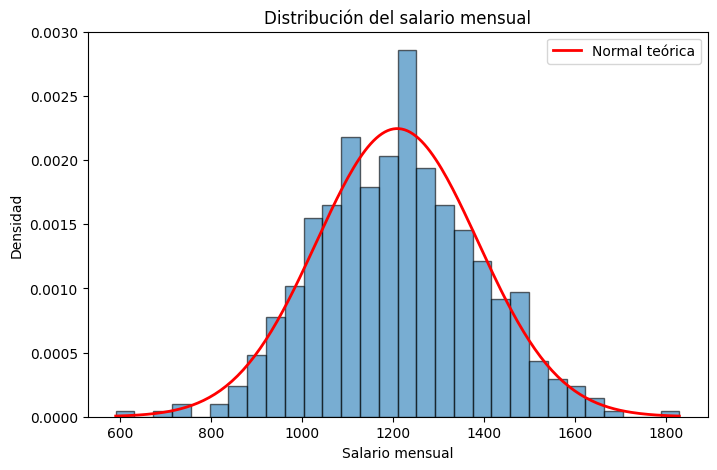

In [ ]:
mu = df['salario_mensual'].mean()
sigma = df['salario_mensual'].std()
print(f"Media: {mu:.2f}, Desvío estándar: {sigma:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['salario_mensual'], bins=30, density=True, alpha=0.6, edgecolor='black')
x = np.linspace(df['salario_mensual'].min(), df['salario_mensual'].max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
ax.set_xlabel('Salario mensual')
ax.set_ylabel('Densidad')
ax.set_title('Distribución del salario mensual')
ax.legend()
plt.show()


### ❓ Pregunta 14
Suponiendo que `salario_mensual` sigue una distribución $N(\mu, \sigma)$ con los parámetros estimados, ¿cuál es la probabilidad de que un empleado elegido al azar gane **más de 1400** (miles de pesos)?

- **a)** 0.050
- **b)** 0.141
- **c)** 0.500
- **d)** 0.859


In [ ]:
#P(X>a)= 1 - P(X<=a)
p_mayor_1400 = 1 - stats.norm.cdf(1400, loc=mu, scale=sigma)
print(f"P(salario > 1400) = {p_mayor_1400:.4f}")


P(salario > 1400) = 0.1411


### ❓ Pregunta 15
¿Cuál es el salario correspondiente al **percentil 90** de la distribución normal ajustada?

- **a)** 1209.00
- **b)** 1300.00
- **c)** 1436.67
- **d)** 1600.00


In [ ]:
percentil_90 = stats.norm.ppf(0.90, loc=mu, scale=sigma)
print(f"Percentil 90 del salario = {percentil_90:.2f}")


Percentil 90 del salario = 1436.67


---
## 7️⃣ Intervalos de confianza para la media

Para una muestra de tamaño $n$, con desvío estándar poblacional desconocido, el intervalo de confianza para la media usa la distribución t de Student:

$$\bar{x} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}}$$

Tomamos una **muestra aleatoria simple de 40 empleados** del dataset (`random_state=1`).

### ❓ Pregunta 16
¿Cuál es el intervalo de confianza del **95%** para la media del `salario_mensual` poblacional, calculado con esta muestra de 40 empleados?

- **a)** (1153.76 ; 1256.19)
- **b)** (1000.00 ; 1400.00)
- **c)** (1143.49 ; 1266.46)
- **d)** (1168.38 ; 1227.12)


In [ ]:
np.random.seed(1)
muestra_40 = df['salario_mensual'].sample(40, random_state=1)

n1 = len(muestra_40)
media_40 = muestra_40.mean()
sem_40 = muestra_40.std(ddof=1) / np.sqrt(n1)

ic_95 = stats.t.interval(0.95, df=n1 - 1, loc=media_40, scale=sem_40)
print(f"Media muestral: {media_40:.2f}")
print(f"IC 95% para la media: ({ic_95[0]:.2f}, {ic_95[1]:.2f})")


Media muestral: 1204.97
IC 95% para la media: (1143.49, 1266.46)


### ❓ Pregunta 17
Con la misma muestra, ¿cuál de las siguientes opciones corresponde al intervalo de confianza del **90%** (más angosto que el del 95%)?

- **a)** (1204.97 ; 1204.97)
- **b)** (1000.00 ; 1400.00)
- **c)** (1153.76 ; 1256.19)
- **d)** (1143.49 ; 1266.46)


In [ ]:
ic_90 = stats.t.interval(0.90, df=n1 - 1, loc=media_40, scale=sem_40)
print(f"IC 90% para la media: ({ic_90[0]:.2f}, {ic_90[1]:.2f})")

ancho_95 = ic_95[1] - ic_95[0]
ancho_90 = ic_90[1] - ic_90[0]
print(f"\nAncho IC 95%: {ancho_95:.2f}")
print(f"Ancho IC 90%: {ancho_90:.2f}")


IC 90% para la media: (1153.76, 1256.19)

Ancho IC 95%: 122.97
Ancho IC 90%: 102.44


### ❓ Pregunta 18
Repitiendo el cálculo del intervalo de confianza del 95% pero con una muestra de tamaño **150** (`random_state=1`), ¿cuál de las siguientes opciones corresponde a ese nuevo intervalo (más angosto que el de n=40)?

- **a)** (1100.00 ; 1300.00)
- **b)** (1168.38 ; 1227.12)
- **c)** (1204.97 ; 1266.46)
- **d)** (1143.49 ; 1266.46)


In [ ]:
muestra_150 = df['salario_mensual'].sample(150, random_state=1)
n2 = len(muestra_150)
media_150 = muestra_150.mean()
sem_150 = muestra_150.std(ddof=1) / np.sqrt(n2)

ic_95_150 = stats.t.interval(0.95, df=n2 - 1, loc=media_150, scale=sem_150)
ancho_150 = ic_95_150[1] - ic_95_150[0]

print(f"IC 95% (n=150): ({ic_95_150[0]:.2f}, {ic_95_150[1]:.2f})  -> ancho = {ancho_150:.2f}")
print(f"IC 95% (n=40):  ({ic_95[0]:.2f}, {ic_95[1]:.2f})  -> ancho = {ancho_95:.2f}")


IC 95% (n=150): (1168.38, 1227.12)  -> ancho = 58.74
IC 95% (n=40):  (1143.49, 1266.46)  -> ancho = 122.97


# REGLA P - VALOR: SI p valor < $\alpha$  => se rechaza $H_{0}$

---
## 8️⃣ Pruebas de hipótesis para la media

Planteamos un contraste de hipótesis sobre la media poblacional del salario, usando la muestra de 40 empleados:

$$H_0: \mu = 1200 \qquad H_1: \mu \neq 1200 \qquad (\alpha = 0.05)$$

Es una **prueba bilateral**, porque la hipótesis alternativa plantea que la media puede ser mayor o menor que 1200.

Recuerda el procedimiento:
1. Plantear $H_0$ y $H_1$.
2. Calcular el estadístico de prueba.
3. Obtener el **p-valor**.
4. Comparar el p-valor con $\alpha$.
5. Tomar una decisión sobre $H_0$ y redactar la conclusión en contexto.


### ❓ Pregunta 19
Al calcular el estadístico t y el p-valor de esta prueba, ¿cuál es la conclusión correcta?

- **a)** No se puede concluir nada sin conocer la varianza poblacional
- **b)** Se rechaza H0: hay evidencia de que la media difiere de 1200
- **c)** No se rechaza H0: no hay evidencia de que la media difiera de 1200
- **d)** Se acepta H1 con muy alta confianza (p < 0.001)


In [ ]:
# Prueba t bilateral para una media
t_stat, p_valor = stats.ttest_1samp(muestra_40, popmean=1200)

print(f"Estadístico t = {t_stat:.4f}")
print(f"p-valor (bilateral) = {p_valor:.4f}")

print("\nCompara el p-valor con alpha = 0.05 para tomar la decisión.")


Estadístico t = 0.1637
p-valor (bilateral) = 0.8708

Compara el p-valor con alpha = 0.05 para tomar la decisión.


### ❓ Pregunta 20
Ahora planteamos una prueba **unilateral** para determinar si el salario medio de los empleados del departamento de **IT** es **mayor** a 1250 (miles de pesos), con $\alpha = 0.05$: $H_0: \mu \le 1250$ vs $H_1: \mu > 1250$.

- **a)** El salario medio en IT es significativamente mayor a 1250 con muy alta confianza (p < 0.01)
- **b)** El estadístico t es positivo, por lo tanto se rechaza H0 automáticamente
- **c)** No se rechaza H0: no hay evidencia suficiente de que el salario medio en IT supere 1250
- **d)** Se rechaza H0: el salario medio en IT es significativamente mayor a 1250


In [ ]:
# Prueba t unilateral derecha
it_salarios = df.loc[df["departamento"] == "IT", "salario_mensual"]

t_stat_it, p_valor_dos_colas = stats.ttest_1samp(
    it_salarios,
    popmean=1250
)

# Como H1: mu > 1250, necesitamos el área de la cola derecha.
if t_stat_it > 0:
    p_valor_unilateral = p_valor_dos_colas / 2
else:
    p_valor_unilateral = 1 - p_valor_dos_colas / 2

print(f"Media muestral IT: {it_salarios.mean():.2f}")
print(f"Estadístico t = {t_stat_it:.4f}")
print(f"p-valor unilateral (H1: μ > 1250) = {p_valor_unilateral:.4f}")

print("\nCompara el p-valor con alpha = 0.05 y decide si se rechaza H0.")


Media muestral IT: 1220.23
Estadístico t = -1.7990
p-valor unilateral (H1: μ > 1250) = 0.9628

Compara el p-valor con alpha = 0.05 y decide si se rechaza H0.


### ❓ Pregunta 21
¿El valor $\mu_0 = 1200$ está dentro del intervalo de confianza del 95% calculado en la Pregunta 16? ¿Es esto consistente con la conclusión de la Pregunta 19?

- **a)** Sí, está dentro del IC, pero de todas formas se debería rechazar H0
- **b)** No, está fuera del IC, lo cual es consistente con rechazar H0
- **c)** No se puede relacionar el IC con la prueba de hipótesis
- **d)** Sí, está dentro del IC, lo cual es consistente con no rechazar H0


In [ ]:
ic_95_muestra40 = stats.t.interval(0.95, df=n1 - 1, loc=media_40, scale=sem_40)
print(f"IC 95% para la media: ({ic_95_muestra40[0]:.2f}, {ic_95_muestra40[1]:.2f})")

mu0 = 1200
dentro = ic_95_muestra40[0] <= mu0 <= ic_95_muestra40[1]
print(f"\n¿mu0=1200 está dentro del IC? {dentro}")


---
## 9️⃣ p-valor

El p-valor es la probabilidad de obtener un estadístico de prueba tan extremo (o más) que el observado, asumiendo que $H_0$ es verdadera.

### ❓ Pregunta 22

Para la prueba de hipótesis de la Pregunta 19 (prueba bilateral, con p-valor ≈ 0.8708), ¿cuál es la interpretación y decisión correctas con $\alpha = 0.05$?

- **a)** Es una probabilidad alta de observar una diferencia tan grande o mayor asumiendo H0 verdadera; por lo tanto, no se rechaza H0
- **b)** Es la probabilidad de rechazar correctamente H0, por lo que se rechaza H0
- **c)** Es la probabilidad de cometer un error de tipo II, por lo que se rechaza H0
- **d)** Es la probabilidad de que H0 sea verdadera; como es alta, se acepta H0 con certeza


In [ ]:
print(f"p-valor obtenido en la Pregunta 19: {p_valor:.4f}")

if p_valor < 0.05:
    print("Con alpha=0.05: se rechaza H0.")
else:
    print("Con alpha=0.05: no se rechaza H0.")


### ❓ Pregunta 23
Con el p-valor unilateral obtenido para la prueba del departamento de IT (Pregunta 20), ¿en cuál de los siguientes niveles de significancia se **rechaza** H0?

- **a)** En los tres niveles (0.01, 0.05 y 0.10)
- **b)** Solo en α = 0.01
- **c)** Solo en α = 0.10
- **d)** En ninguno de los tres (0.01, 0.05 y 0.10)


In [ ]:
for alpha in [0.01, 0.05, 0.10]:
    decision = "se rechaza H0" if p_valor_unilateral < alpha else "no se rechaza H0"
    print(f"alpha = {alpha:>4}: p-valor = {p_valor_unilateral:.4f} -> {decision}")


alpha = 0.01: p-valor = 0.9628 -> no se rechaza H0
alpha = 0.05: p-valor = 0.9628 -> no se rechaza H0
alpha =  0.1: p-valor = 0.9628 -> no se rechaza H0


### ❓ Pregunta 24 — Nueva prueba unilateral

Ahora queremos determinar si el **salario medio de los empleados de Ventas es menor que 1250** (miles de pesos), con $\alpha = 0.05$.

Plantea y analiza:

$$H_0: \mu \geq 1250$$

$$H_1: \mu < 1250$$

Esta es una **prueba unilateral de cola izquierda**.

¿Cuál es la conclusión correcta?

- **a)** Se rechaza $H_0$: existe evidencia de que el salario medio en Ventas es menor que 1250.
- **b)** No se rechaza $H_0$: no existe evidencia suficiente de que el salario medio en Ventas sea menor que 1250.
- **c)** Se rechaza $H_0$ automáticamente porque la media muestral es menor que 1250.
- **d)** No se puede realizar la prueba porque se desconoce la varianza poblacional.


In [ ]:
# Prueba t unilateral de cola izquierda
ventas_salarios = df.loc[df["departamento"] == "Ventas", "salario_mensual"]

t_stat_ventas, p_valor_dos_colas_ventas = stats.ttest_1samp(
    ventas_salarios,
    popmean=1250
)

# Para H1: μ < 1250, necesitamos el área de la cola izquierda.
if t_stat_ventas < 0:
    p_valor_unilateral_izq = p_valor_dos_colas_ventas / 2
else:
    p_valor_unilateral_izq = 1 - p_valor_dos_colas_ventas / 2

print(f"Media muestral Ventas: {ventas_salarios.mean():.2f}")
print(f"Estadístico t = {t_stat_ventas:.4f}")
print(f"p-valor unilateral (H1: μ < 1250) = {p_valor_unilateral_izq:.6f}")

print("\nCompara el p-valor con alpha = 0.05.")
print("Recuerda: si p-valor < alpha, se rechaza H0.")


---
## 🔟 Tipos de muestreo

Repasamos tres tipos de muestreo probabilístico:
- **Aleatorio simple**: cada elemento tiene la misma probabilidad de ser seleccionado.
- **Estratificado**: se divide la población en estratos (grupos homogéneos) y se muestrea dentro de cada uno, respetando proporciones.
- **Por conglomerados (clusters)**: se divide la población en grupos heterogéneos (conglomerados) y se seleccionan conglomerados completos al azar.

Realizamos un **muestreo aleatorio simple** de 50 empleados y un **muestreo estratificado** de 50 empleados usando `departamento` como variable de estratificación (`random_state=7` en ambos casos). La proporción poblacional de `Ventas` es 0.308.

### ❓ Pregunta 24
¿Cuál de los dos muestreos (aleatorio simple o estratificado) replicó de forma más exacta la proporción poblacional de `Ventas` (0.308)?

- **a)** El muestreo aleatorio simple
- **b)** El muestreo estratificado
- **c)** Ninguno de los dos se acercó a 0.308
- **d)** Ambos la replicaron de forma exactamente igual


In [ ]:
muestra_mas = df.sample(50, random_state=7)

partes = []
for depto, grupo in df.groupby('departamento'):
    partes.append(grupo.sample(frac=50 / len(df), random_state=7))
muestra_estrat = pd.concat(partes)

print("Proporción de 'Ventas' en la población:", (df['departamento'] == 'Ventas').mean())
print("Proporción de 'Ventas' - Muestreo Aleatorio Simple:",
      (muestra_mas['departamento'] == 'Ventas').mean())
print("Proporción de 'Ventas' - Muestreo Estratificado:",
      (muestra_estrat['departamento'] == 'Ventas').mean())


### ❓ Pregunta 25
Ahora realizamos un **muestreo por conglomerados**, usando `region` como conglomerado: seleccionamos al azar 2 de las 3 regiones y tomamos **todos** los empleados de esas regiones como muestra. ¿Qué característica distingue a este muestreo frente a los dos anteriores (de tamaño 50)?

- **a)** Se seleccionaron individuos al azar dentro de cada región, igual que en el estratificado
- **b)** Es un método idéntico al muestreo estratificado
- **c)** El tamaño de la muestra resultante fue mucho mayor, porque se toman todos los individuos de los conglomerados seleccionados
- **d)** El tamaño de la muestra fue igual a 50, igual que en los otros métodos


In [ ]:
np.random.seed(3)
regiones_seleccionadas = np.random.choice(df['region'].unique(), size=2, replace=False)
muestra_conglomerados = df[df['region'].isin(regiones_seleccionadas)]

print(f"Regiones seleccionadas como conglomerados: {list(regiones_seleccionadas)}")
print(f"Tamaño de la muestra por conglomerados: {len(muestra_conglomerados)}")
print(f"Tamaño de la muestra aleatoria simple: {len(muestra_mas)}")
print(f"Tamaño de la muestra estratificada: {len(muestra_estrat)}")


---
# ✅ Clave de respuestas

Usá esta clave solo para autocorregirte después de haber respondido cada pregunta.

| Pregunta | Respuesta | Pregunta | Respuesta | Pregunta | Respuesta |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | a | 10 | b | 19 | c |
| 2 | a | 11 | a | 20 | c |
| 3 | b | 12 | a | 21 | d |
| 4 | d | 13 | d | 22 | a |
| 5 | b | 14 | b | 23 | d |
| 6 | c | 15 | c | 24 | a |
| 7 | a | 16 | c | 25 | b |
| 8 | b | 17 | c | 26 | c |
| 9 | c | 18 | b |  |  |


---
## 🎯 Cierre

¡Listo! Repasaste los conceptos centrales del módulo de inferencia estadística:
probabilidad clásica, tablas de doble entrada, árboles de probabilidad, unión e
intersección, probabilidad condicional, distribución normal, intervalos de
confianza, pruebas de hipótesis, p-valor y tipos de muestreo.

Podés modificar la semilla (`np.random.seed`) o los parámetros de generación del
dataset para practicar con distintos escenarios y valores.